In [72]:
import pandas as pd
import numpy as np
import warnings
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

warnings.filterwarnings('ignore')


train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
full = pd.concat([train, test], axis=0).reset_index(drop=True)
train_len = len(train)


In [73]:
def feature_engineering(full):
    df = full.copy()
    # ── 1. PassengerId ──────────────────────────────────
    df['GroupId']     = df['PassengerId'].str.split('_').str[0].astype(int)
    df['GroupMember'] = df['PassengerId'].str.split('_').str[1].astype(int)
    df['GroupSize']   = df.groupby('GroupId')['PassengerId'].transform('count')
    df['IsAlone']     = (df['GroupSize'] == 1).astype(int)

    # ── 2. Cabin ────────────────────────────────────────
    df['Cabin']       = df['Cabin'].fillna('U/0/U')
    df['Deck']        = df['Cabin'].str.split('/').str[0]
    df['CabinNum']    = df['Cabin'].str.split('/').str[1].astype(float)
    df['Side']        = df['Cabin'].str.split('/').str[2]
    df['CabinRegion'] = pd.cut(
        df['CabinNum'],
        bins=[0, 300, 600, 900, 1200, 1800],
        labels=[1, 2, 3, 4, 5]
    ).astype(float)

    # ── 3. 布尔列统一处理 ───────────────────────────────
    for col in ['CryoSleep', 'VIP']:
        df[col] = df[col].map(
            {True: 1, False: 0, 'True': 1, 'False': 0}
        ).fillna(-1)

    # ── 4. 消费特征 ─────────────────────────────────────
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

    # CryoSleep=1 的人消费理论为0，用0填充；其余用中位数
    for col in spend_cols:
        median_val = df.loc[df['CryoSleep'] != 1, col].median()
        df.loc[df['CryoSleep'] == 1, col] = df.loc[df['CryoSleep'] == 1, col].fillna(0)
        df[col] = df[col].fillna(median_val)

    df['TotalSpend']   = df[spend_cols].sum(axis=1)
    df['LuxurySpend']  = df[['Spa', 'VRDeck', 'RoomService']].sum(axis=1)
    df['BasicSpend']   = df[['FoodCourt', 'ShoppingMall']].sum(axis=1)
    df['NoSpend']      = (df['TotalSpend'] == 0).astype(int)
    df['SpendCount']   = (df[spend_cols] > 0).sum(axis=1)
    df['LuxuryShare'] = (df['Spa'] + df['VRDeck']) / (df['TotalSpend'] + 1)
    for col in spend_cols:
        df[f'{col}_ratio'] = df[col] / (df['TotalSpend'] + 1)
    for col in spend_cols + ['TotalSpend', 'LuxurySpend', 'BasicSpend']:
        df[f'log_{col}'] = np.log1p(df[col])

    # ── 5. 团体聚合 ─────────────────────────────────────
    for col in spend_cols + ['TotalSpend']:
        grp = df.groupby('GroupId')[col]
        df[f'Grp_{col}_sum']  = grp.transform('sum')
        df[f'Grp_{col}_std']  = grp.transform('std').fillna(0)

    df['Grp_Cryo_ratio'] = df.groupby('GroupId')['CryoSleep'].transform('mean')
    df['Grp_VIP_ratio']  = df.groupby('GroupId')['VIP'].transform('mean')
    df['SpendPerMember'] = df['TotalSpend'] / df['GroupSize']

    # ── 6. 年龄 ─────────────────────────────────────────
    df['HomePlanet'] = df['HomePlanet'].fillna('Unknown')
    df['Destination'] = df['Destination'].fillna('Unknown')

    df['Age'] = df.groupby(['HomePlanet', 'Deck'])['Age'].transform(
        lambda x: x.fillna(x.median())
    )
    df['Age'] = df['Age'].fillna(df['Age'].median())
    # df['IsChild'] = (df['Age'] < 13).astype(int)
    df['AgeGroup'] = pd.cut(
        df['Age'],
        bins=[0, 12, 18, 30, 45, 65, 200],
        labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'MiddleAge', 'Senior']
    ).astype(str)

    # ── 7. 交叉特征 ─────────────────────────────────────
    df['DeckSide']  = df['Deck'] + '_' + df['Side']
    df['Route']     = df['HomePlanet'] + '_to_' + df['Destination']
    df['VIP_Planet'] = df['VIP'].astype(str) + '_' + df['HomePlanet']
    df['DeckSide_NoSpend'] = df['DeckSide'] + '_' + df['NoSpend'].astype(str)
    # ── 8.GPT给的特征 ─────────────────────────────────────

    return df

full = feature_engineering(full)

In [74]:
# ????? LightGBM ???????? Optuna ?????
LGB_PARAMS = {
    'n_estimators': 641,
    'learning_rate': 0.029535541041042793,
    'num_leaves': 28,
    'max_depth': 8,
    'subsample': 0.8025174191733238,
    'colsample_bytree': 0.7392895187477424,
    'reg_alpha': 1.330574389771076,
    'reg_lambda': 5.6611887203689975,
    'min_child_samples': 103,
    'objective': 'binary',
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': -1,
}


In [75]:
def train_lightgbm_kfold(X, X_test, y, cat_cols, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof = np.zeros(len(X))
    pred = np.zeros(len(X_test))

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model = LGBMClassifier(**LGB_PARAMS)
        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_val, y_val)],
            eval_metric='binary_error',
            categorical_feature=cat_cols,
            callbacks=[
                early_stopping(stopping_rounds=200, verbose=False),
                log_evaluation(period=0)
            ]
        )

        train_pred = model.predict_proba(X_tr)[:, 1]
        val_pred = model.predict_proba(X_val)[:, 1]

        train_acc = accuracy_score(y_tr, (train_pred > 0.5).astype(int))
        val_acc = accuracy_score(y_val, (val_pred > 0.5).astype(int))

        oof[val_idx] = val_pred
        pred += model.predict_proba(X_test)[:, 1] / n_splits

        print(
            f"Fold {fold+1} | "
            f"train_acc={train_acc:.4f} | "
            f"val_acc={val_acc:.4f} | "
            f"gap={train_acc - val_acc:.4f} | "
            f"best_iter={model.best_iteration_}"
        )

    oof_score = accuracy_score(y, (oof > 0.5).astype(int))
    print(f"OOF Accuracy = {oof_score:.4f}")
    return oof, pred, oof_score

# print("=" * 55)
# print("Training LightGBM ...")
# lgb_oof, lgb_pred = train_lightgbm_kfold(X_lgb, X_test_lgb, y, cat_cols_lgb)

In [76]:
def prepare_lightgbm_v3(full, train_len, drop_feature_groups=None, candidate_groups=None):
    df = full.copy()

    drop_cols = ['PassengerId', 'Name', 'Cabin', 'Transported']
    df = df.drop(columns=drop_cols, errors='ignore').copy()

    cat_cols = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])]
    for c in cat_cols:
        df[c] = df[c].fillna('Unknown').astype('category')

    X = df.iloc[:train_len].copy()
    X_test = df.iloc[train_len:].copy()
    y = full['Transported'][:train_len].map(
        {True: 1, False: 0, 'True': 1, 'False': 0}
    ).astype(int)

    dropped_cols = []
    return X, X_test, y, cat_cols, dropped_cols


In [77]:
# ??????????????
X_lgb, X_test_lgb, y, cat_cols_lgb, dropped_cols = prepare_lightgbm_v3(
    full,
    train_len,
    drop_feature_groups=[],
    candidate_groups=[]
)

oof, pred, oof_score = train_lightgbm_kfold(
    X_lgb,
    X_test_lgb,
    y,
    cat_cols_lgb,
    n_splits=5
)

thresholds = np.arange(0.40, 0.60, 0.005)
scores = [accuracy_score(y, (oof > t).astype(int)) for t in thresholds]
best_t = thresholds[np.argmax(scores)]
best_s = max(scores)

final_pred = (pred > best_t).astype(bool)
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Transported': final_pred
})
submission.to_csv('submission_lightgbm_best_old.csv', index=False)

print(f'提交文件: submission_lightgbm_best.csv')
print(f'实际删除列: {dropped_cols}')
print(f'OOF Accuracy@0.5: {oof_score:.4f}')
print(f'Best Threshold: {best_t:.3f}')
print(f'Best Accuracy: {best_s:.4f}')
print(f'预测分布:\n{submission["Transported"].value_counts()}')


Fold 1 | train_acc=0.8842 | val_acc=0.8235 | gap=0.0608 | best_iter=429
Fold 2 | train_acc=0.8548 | val_acc=0.8120 | gap=0.0428 | best_iter=177
Fold 3 | train_acc=0.8527 | val_acc=0.8235 | gap=0.0293 | best_iter=176
Fold 4 | train_acc=0.8591 | val_acc=0.8280 | gap=0.0311 | best_iter=237
Fold 5 | train_acc=0.8739 | val_acc=0.8090 | gap=0.0649 | best_iter=325
OOF Accuracy = 0.8192
提交文件: submission_lightgbm_best.csv
实际删除列: []
OOF Accuracy@0.5: 0.8192
Best Threshold: 0.500
Best Accuracy: 0.8192
预测分布:
Transported
True     2159
False    2118
Name: count, dtype: int64


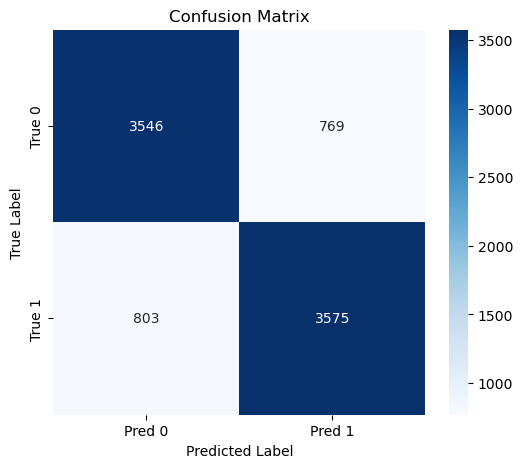

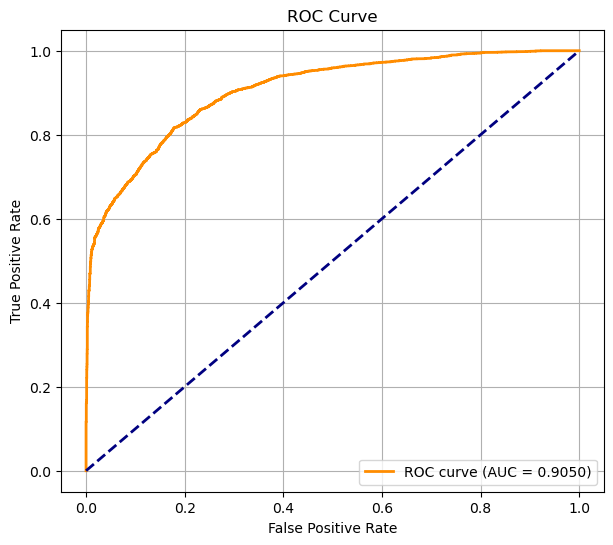

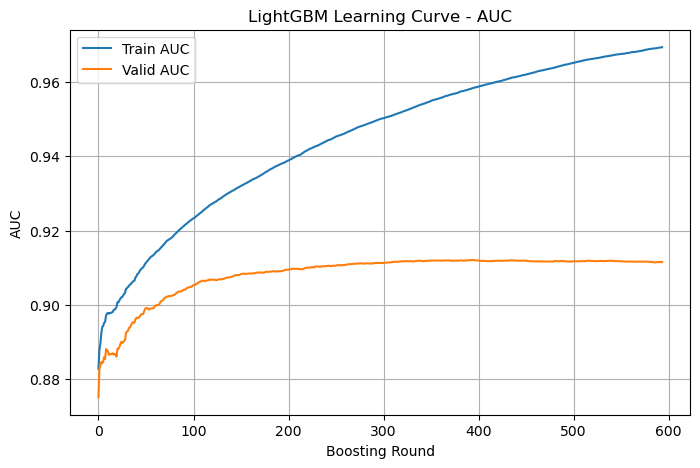

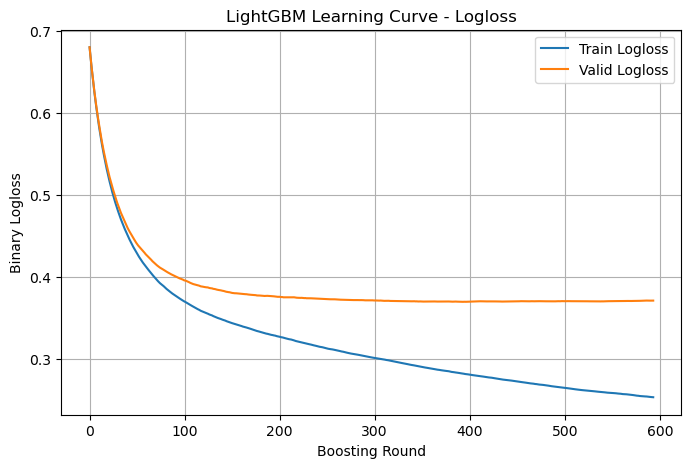

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

# =========================
# 1. Confusion Matrix
# =========================
y_true = y
y_prob = oof
y_pred = (y_prob > best_t).astype(int)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pred 0', 'Pred 1'],
    yticklabels=['True 0', 'True 1']
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# =========================
# 2. ROC Curve
# =========================
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# =========================
# 3. Learning Curves
# =========================
X_train_part, X_valid_part, y_train_part, y_valid_part = train_test_split(
    X_lgb,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

lgb_curve_model = LGBMClassifier(**LGB_PARAMS)

lgb_curve_model.fit(
    X_train_part,
    y_train_part,
    eval_set=[(X_train_part, y_train_part), (X_valid_part, y_valid_part)],
    eval_metric=['binary_logloss', 'auc'],
    categorical_feature=cat_cols_lgb,
    callbacks=[
        early_stopping(stopping_rounds=200, verbose=False),
        log_evaluation(period=0)
    ]
)

results = lgb_curve_model.evals_result_

plt.figure(figsize=(8, 5))
plt.plot(results['training']['auc'], label='Train AUC')
plt.plot(results['valid_1']['auc'], label='Valid AUC')
plt.xlabel('Boosting Round')
plt.ylabel('AUC')
plt.title('LightGBM Learning Curve - AUC')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(results['training']['binary_logloss'], label='Train Logloss')
plt.plot(results['valid_1']['binary_logloss'], label='Valid Logloss')
plt.xlabel('Boosting Round')
plt.ylabel('Binary Logloss')
plt.title('LightGBM Learning Curve - Logloss')
plt.legend()
plt.grid(True)
plt.show()
